# FA minibatch

In [1]:
import torch
import math
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from torch import nn

In [2]:
N = 500
M = 2
sigmav2 = 0.01
mu = 0.5

u = np.random.randn(N)
wo = [2, -3]
d = signal.lfilter(wo, 1, u) + np.sqrt(sigmav2) * np.random.randn(N)

In [3]:
def LMS_FILTER(u, d, mu, M):
    N = len(u)
    uM = np.zeros(M)
    y = np.zeros(N)
    e = np.zeros(N)
    W = np.zeros((N + 1, M))
    for i in range(N):
        uM = np.concatenate((u[i : i + 1], uM[0 : M - 1]))
        y[i] = uM @ W[i, :]
        e[i] = d[i] - y[i]
        W[i + 1, :] = W[i, :] + mu * e[i] * uM
    return y, e, W

(0.0, 500.0, -3.5, 2.5)

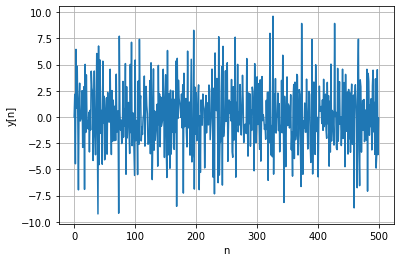

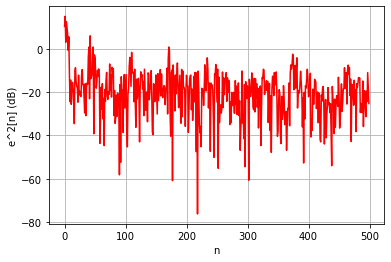

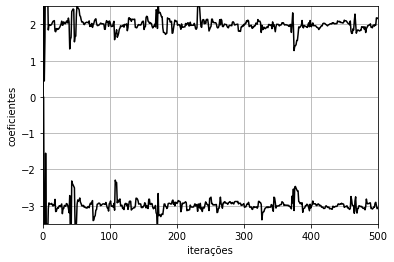

In [4]:
(y, e, W) = LMS_FILTER(u, d, mu, M)

plt.figure()
plt.plot(y)
plt.xlabel("n")
plt.ylabel("y[n]")
plt.grid()

edb = 10 * np.log10(e**2)
plt.figure()
plt.plot(edb, "r")
plt.xlabel("n")
plt.ylabel("e^2[n] (dB)")
plt.grid()

plt.figure()
plt.plot(W, "k")
plt.xlabel("iterações")
plt.ylabel("coeficientes")
plt.grid()
plt.axis([0, N, min(wo) - 0.5, max(wo) + 0.5])

In [5]:
def LMS_FILTER_batch(u, mu, M, Ne, wo):
    N = len(u)
    uM = np.zeros(M)
    y = np.zeros(N)
    e = np.zeros(N)
    W = np.zeros((Ne + 1, M))
    G = np.zeros((1,M))
    mu=mu/N
    for k in range(Ne):
        np.random.shuffle(u)
        d = signal.lfilter(wo, 1, u) + np.sqrt(sigmav2) * np.random.randn(N)
        for i in range(N):
            uM = np.concatenate((u[i : i + 1], uM[0 : M - 1]))
            y[i] = uM @ W[k, :]
            e[i] = d[i] - y[i]
            G = G + e[i] * uM
        W[k + 1, :] = W[k, :] + mu * G
        G = np.zeros((1,M))
        uM = np.zeros(M)
    return y, e, W

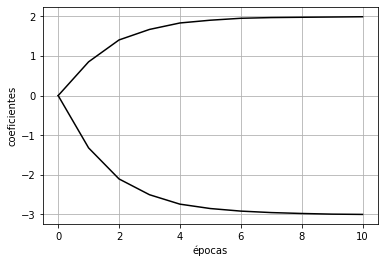

In [6]:
Ne=10
(y, e, Wb) = LMS_FILTER_batch(u, mu, M, Ne, wo)
plt.figure()
plt.plot(Wb, "k")
plt.xlabel("épocas")
plt.ylabel("coeficientes")
plt.grid()



In [7]:
def LMS_FILTER_minibatch(u, mu, M, Ne, Nb, wo):
    N = len(u)
    uM = np.zeros(M)
    y = np.zeros(N)
    e = np.zeros(N)
    W = np.zeros((Ne*int(N/Nb) + 1, M))
    Waux = np.zeros((1,M))
    G = np.zeros((1,M))
    mu=mu/Nb
    m=1;
    for k in range(Ne):
        n=1;
        np.random.shuffle(u)
        d = signal.lfilter(wo, 1, u) + np.sqrt(sigmav2) * np.random.randn(N)
        for i in range(N):
            uM = np.concatenate((u[i : i + 1], uM[0 : M - 1]))
            y[i] = uM @ Waux[0,:]
            e[i] = d[i] - y[i]
            G[0,:] = G[0,:] + e[i] * uM
            if (i==(n*Nb-1)):
                Waux[0,:] = Waux[0,:] + mu * G[0,:]
                W[m,:]=Waux[0,:]
                m=m+1
                n=n+1
                G = np.zeros((1,M))
    return y, e, W

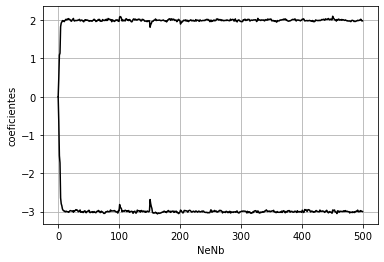

In [8]:
Ne = 10 
Nb = 10
(y, e, Wm) = LMS_FILTER_minibatch(u, mu, M, Ne, Nb, wo)
plt.figure()
plt.plot(Wm, "k")
plt.xlabel("NeNb")
plt.ylabel("coeficientes")
plt.grid()